<h1 style="color:darkgreen; background-color:white; text-align:center;">بسم الله الرحمن الرحيم </h1>

In [1]:
import numpy as np 
import pandas as pd

from sklearn.model_selection import train_test_split 
from sklearn.model_selection import GridSearchCV 
from sklearn.cluster import DBSCAN, KMeans 
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns 
import plotly.express as px
import plotly.graph_objects as go

In [2]:
PATH = r"./datasets/customer_segmentation.csv"
data = pd.read_csv(PATH)
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [3]:
data.drop(["ID"], axis=1, inplace=True)
data.drop_duplicates(inplace=True)

In [4]:
encoder = LabelEncoder()
data["Education"] = encoder.fit_transform(data['Education'])
data["Marital_Status"] = encoder.fit_transform(data["Marital_Status"])
data["date_month"] = data["Dt_Customer"].apply(lambda x : int(x[3:5]))
data["date_year"] = data["Dt_Customer"].apply(lambda x : int(x[6:]))
data.drop(["Dt_Customer"], axis=1, inplace=True)

In [5]:
def remove_outliers_iqr(df=data, column_name=""):
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    cleaned_df = df[(df[column_name] >= lower_bound) & (df[column_name] <= upper_bound)]
    return cleaned_df

In [6]:
outliers_cols = []
cleaned_data = data.copy()
for col in cleaned_data.select_dtypes(include=['int64', 'float64']).columns:
    num_unique = cleaned_data[col].nunique()
    if num_unique > (cleaned_data.shape[0] / 4):
        # Remove outliers using IQR for this column
        cleaned_data = remove_outliers_iqr(cleaned_data, col)
        outliers_cols.append(col)

In [7]:
print("origen data: ", data.shape)
print("cleaned data: ", cleaned_data.shape)

origen data:  (2058, 29)
cleaned data:  (1808, 29)


In [8]:
import plotly.express as px

for col in outliers_cols:
    fig = px.box(cleaned_data, y=col, title=f'Boxplot of {col}',
                 color_discrete_sequence=['royalblue'])
    fig.update_layout(height=400, width=600)
    fig.show()


In [9]:
scaler = MinMaxScaler()
data_norm = pd.DataFrame(scaler.fit_transform(data[outliers_cols]), columns=outliers_cols)

In [10]:

def plot_comparison(original, scaled, title):
    for col in outliers_cols:
        fig = go.Figure()
        fig.add_trace(go.Box(y=original[col], name='Original', boxpoints='all', jitter=0.3))
        fig.add_trace(go.Box(y=scaled[col], name=title, boxpoints='all', jitter=0.3))
        fig.update_layout(title=f'{col}: Original vs {title}', height=400)
        fig.show()

plot_comparison(data, data_norm, "Normalized")
plot_comparison(data, data_norm, "Standardized")

In [13]:
numeric_cols = data.select_dtypes(include='number').columns
corr_matrix = data[numeric_cols].corr()

fig = go.Figure(data=go.Heatmap(
    z=corr_matrix.values,
    x=corr_matrix.columns,
    y=corr_matrix.columns,
    colorscale='Viridis',
    zmin=-1, zmax=1
))
fig.update_layout(title='Correlation Heatmap')
fig.show()

In [11]:
corr_matrix = data.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Drop features with correlation > 0.9
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]
df_cluster_filtered = data.drop(columns=to_drop)


In [12]:
numeric_cols = data.select_dtypes(include='number').columns
corr_matrix = data[numeric_cols].corr()

fig = go.Figure(data=go.Heatmap(
    z=corr_matrix.values,
    x=corr_matrix.columns,
    y=corr_matrix.columns,
    colorscale='Viridis',
    zmin=-1, zmax=1
))
fig.update_layout(title='Correlation Heatmap')
fig.show()

In [ ]:
X = cleaned_data[[
    'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency',
    'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
    'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases',
    'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
    'NumWebVisitsMonth', 'AcceptedCmp1', 'AcceptedCmp2',
    'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5',
    'Complain'
    ]
]

In [17]:
kmeans = KMeans(n_clusters=4, random_state=0)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
centroids_pca = pca.transform(kmeans.cluster_centers_)

/home/tlk/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but PCA was fitted with feature names



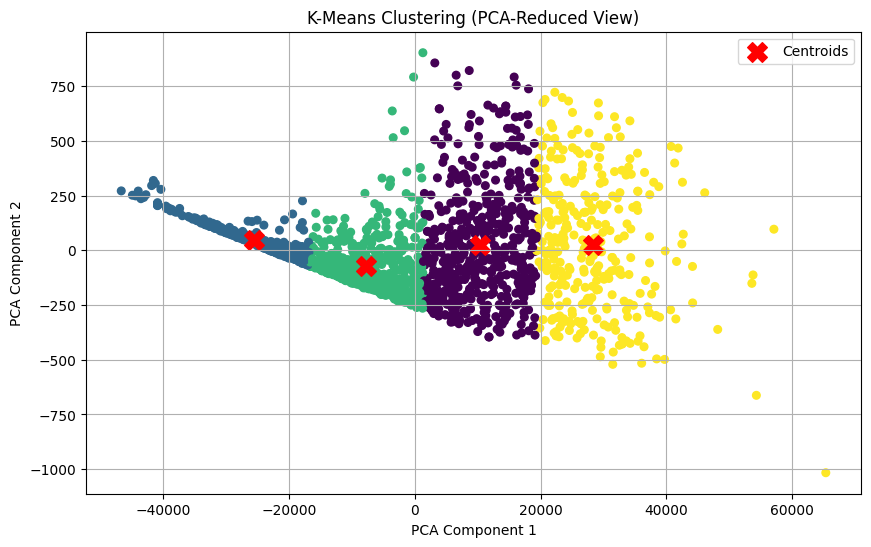

In [18]:
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_kmeans, cmap='viridis', s=30)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], 
            c='red', s=200, marker='X', label='Centroids')
plt.title("K-Means Clustering (PCA-Reduced View)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.grid(True)
plt.show()